<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

In [1]:
# PASO 1: CARGAR Y EXPLORACIÓN INICIAL DE LOS DATOS 

import pandas as pd

df = pd.read_csv('/datasets/games.csv')

print (df.info())
print (df.head())
print (df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29

PASO 1: 
En este paso se cargó el dataset de videojuegos que contiene información histórica de las ventas, con variables de reseña, genero, plataforma y clasificación por edades. Tras revisar los valores se puede observar que se cuenta con 16715 registros y 11 columnas. En las columnas de 'name' y 'genre faltan se observan 2 valores ausentes en cada una, pero en 'years_of_release' hay 269 valores faltantes y en las columnas de 'critic_score', 'user_score' y 'rating hay una gran cantidad de valores faltantes. Tambien, se observan problemas con los tipos de datos, ya que years_of_release esta como float y user_score esta como object. Los valores faltantes en 'critic_score' y 'user_score' sugiere que no todos los juegos fueron evaluados y eso podría afectar el analisis de los datos.

In [2]:
# PASO 2: PREPARACIÓN DE DATOS 

# 2.1 Los nombres de las columnas deben ser en minúscula

df.columns = df.columns.str.lower()
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Se estandarizaron de los nombres de las columnas a minúsculas para mejorar la consistencia del análisis.

In [3]:
# 2.2 Exploración inicial de valores

df.isna().sum()
df['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

Se identificaron valores ausentes y se detectó la presencia de "tbd" en user_score, lo que indica puntuaciones aún no definidas.

In [4]:
2.3 # Limpieza de 'user_score'

df['user_score'] = df['user_score'].replace('tbd', None)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# Verificación 
print(df['user_score'].dtype)
print(df['user_score'].isna().sum())

float64
7955


Se reemplazaron valores "tbd" por nulos y se convirtió la columna a tipo numérico para permitir análisis estadístico.

In [5]:
# 2.4 Conversión de 'year_of_release'

df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')

# Verificación 

print(df['year_of_release'].dtype)
print(df['year_of_release'].isna().sum())
print(df['year_of_release'].describe())

float64
269
count    16446.000000
mean      2006.484616
std          5.877050
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64


Se convirtió la columna a tipo numérico. Los valores inválidos fueron transformados en NaN.

In [6]:
# 2.5 Analisis de Valores Ausentes 

df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         7955
rating             6766
dtype: int64

Se observa valores ausentes en las columnas 'year_of_release', 'critic_score','user_score' y rating 

In [7]:
# 2.6 Tratamiento de los valores ausentes

# Eliminación de filas sin año 

df = df.dropna(subset=['year_of_release'])

# Verificaicón 

df['year_of_release'].isna().sum()

0

Se eliminaron los registros qie no conteniasn nombre o genero ya que son variables eseciales en el análisis. 

In [8]:
# Tratamiento de los valores ausentes 'rating'

df['rating'] = df['rating'].fillna('Unknown')

# Verificación de los valores despues del tratamiento 

print(df['rating'].isna().sum())
print(df['rating'].unique())
print(df['rating'].value_counts())

0
['E' 'Unknown' 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']
Unknown    6678
E          3921
T          2905
M          1536
E10+       1393
EC            8
K-A           3
AO            1
RP            1
Name: rating, dtype: int64


El la columna 'rating'se reeemplazaron los valores ausentes por 'Unkown'

In [9]:
# Tratamiento en 'year_of_release'

df = df.dropna(subset=['year_of_release'])

# Verificación

df['year_of_release'].isna().sum()

0

Se eliminan los registros sin año de lanzamiento ya que esta variable es importante para el análisis.

In [10]:
# 2.7 Crear la columna de ventas totales

df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Unknown,31.38


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


Se crea la variable de ventas totales la cual representa las ventas totales de cada videojuego a nivel mundial, esto nos permite comparar juegos a nivel global, identificar titulos mas exitosos y analizar rentabilidad por plataforma o genero. 

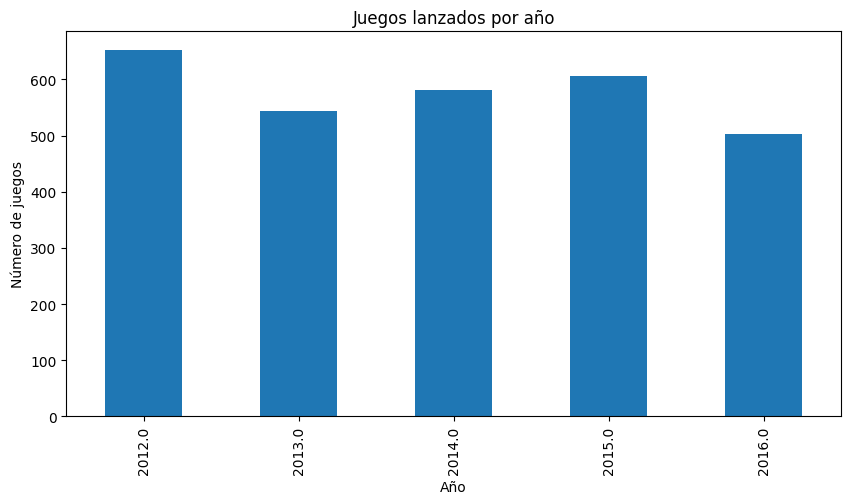

In [11]:
# PASO 3: ANALISIS EXPLORATORIO

# 3.1 Juegos lanzados por año 

df_recent = df[df['year_of_release'] >= 2012]

import matplotlib.pyplot as plt

df_recent.groupby('year_of_release')['name'].count().plot(
    kind='bar',
    figsize=(10,5),
    title="Juegos lanzados por año"
)

plt.xlabel("Año")
plt.ylabel("Número de juegos")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La manera de mostrar los datos me parece correcta.

Recomiendo ampliar los años para tener una mejor visión de la evolución de los videojuegos    
</div>


El analisis de juegos lanzados por año muest que el mayor volumen se concentra en el año 2012, seguido de 2015, 2014 y 2013. Despues del 2015 el número de lanzamientos se disminuye o estabiliza, lo que puede reflejar una posible estabilización del mercado. para la campaña de 2017 los datos mas recientes son los mas relevantes ya que refeljan el comportamiento actual de la industria.

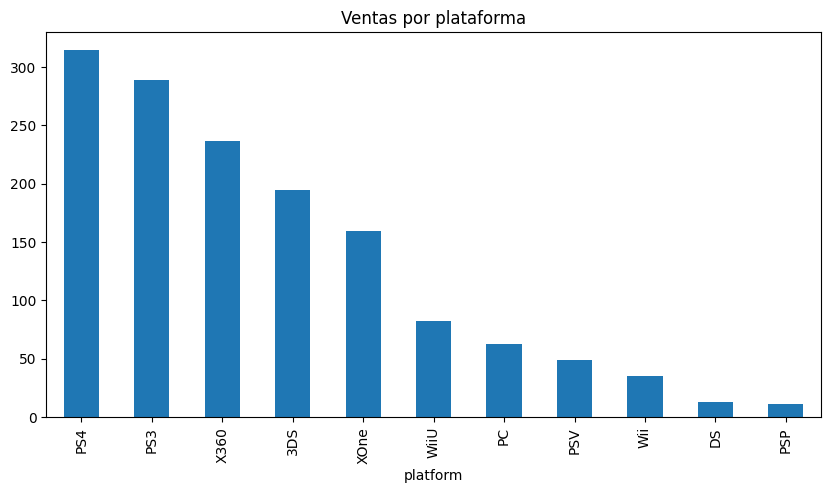

In [13]:
# 3.2 Ventas totales por plataforma 

df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5),
    title="Ventas por plataforma"
)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Gracias a la gráfica podemos ver que hay una diferencia significativa entre los primeros elementos y el resto de plataformas
</div>


El nálisis de ventas por plataforma muestra una clara concentración del mercado en pocas consolas. PS4 lidera las ventas globales, seguido de PS3, Xbox 360, 3DS, Xbox One Y Wii, mientras que el resto presentan un volumen significativamente menor. Esto indica que la industria de videojuegos esta dominadada por un número reducido de plataformas. Además, se observaa que las plataformas mas exitosas corresponden a generaciones recientes. Para la campaña de 2017, las plataformas mas relevantes son PS4 y Xbox One, ya que concentran el crecimiento reciente del mercado.

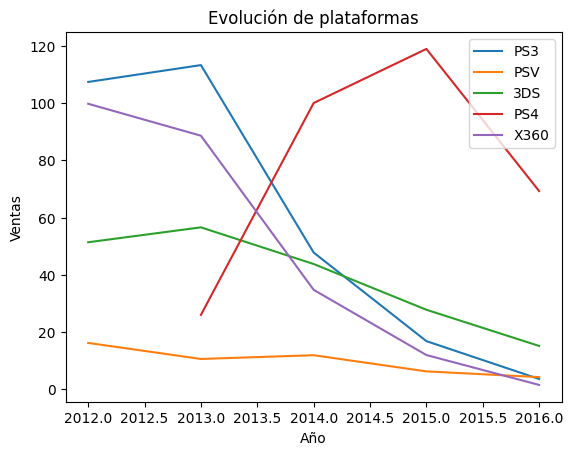

In [14]:
# 3.3 Evolución de plataformas en el tiempo

import matplotlib.pyplot as plt

platform_year = df_recent.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

for p in df_recent['platform'].value_counts().head(5).index:
    data = platform_year[platform_year['platform'] == p]
    plt.plot(data['year_of_release'], data['total_sales'], label=p)

plt.legend()
plt.title("Evolución de plataformas")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos observar el ciclo de vida de las plataformas. Cuando una nueva surge las demás empiezan a caer
</div>


El análisis de la evolución de ventas por plataforma muestra que variasn consolas alcanzaron su punto máximo alrededor del 2013, mientras la PS4 presenta sy pico en 2015, lo que refleja un cambio generacional en el mercado de videojuegos. este comportamiento confirma que las plataformas tienen un ciclo de vida limitado y que el mercado esta en constant renovación. Para la campaña de 2017 se recomienda enfocarse en plataformas mas recientes como PS4.

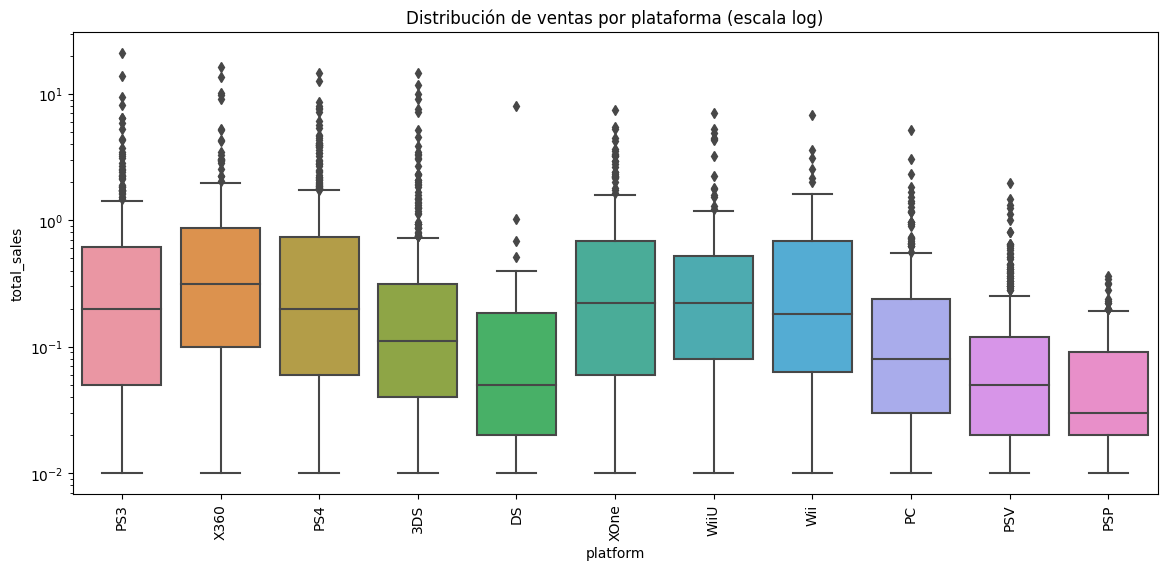

In [15]:
# 3.4 Distribución de ventas por plataforma (Boxplot)

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(14,6))

sns.boxplot(data=df_recent, x='platform', y='total_sales')

plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Distribución de ventas por plataforma (escala log)")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

El diagrama de caja nos muestra como en algunas plataformas las ventas estan consolidadas mientras que en otras consolas las ventas son muy disparejas lo que incrementa el rango intercuartil. Excelente uso de `ylog()`
</div>


El boxplot muestra que la mayoria de los juegos tienen ventas bajas, mientras que unos pocos tienen valores extremadamente altos, lo que indica que pocos juegos concentran gran parte del mercado. Para mejorar la visualización se uso una escala logarítmica para observar mejor la variabiliad de los datos. Este comportamiento indica que la industria de videojuegos depende en gran mediad de unos pocos juegos exitosos.

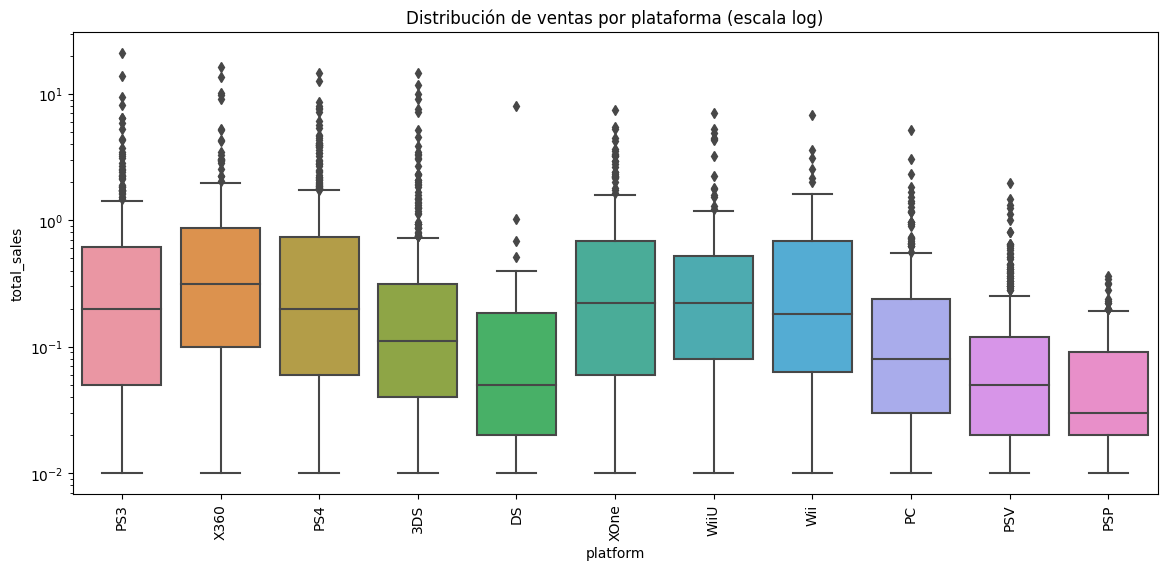

In [17]:
# 3.5 Reseñas Vs Ventas

plt.figure(figsize=(14,6))

sns.boxplot(data=df_recent, x='platform', y='total_sales')

plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Distribución de ventas por plataforma (escala log)")
plt.show()

El análisis de la relación entre las reseñas y las ventas en la plataforma PS4 indica que las puntuaciones de los usuarios no determinan el éxito comercial de un videojuego. Igualmente, se utilizó la escala logarítmica para mejorar la visialuzación de los datos 

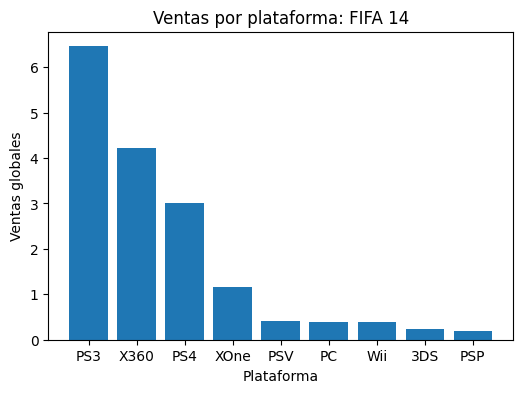

In [18]:
# 3.6 Comparación de juegos entre plataformas

import matplotlib.pyplot as plt

# Elegimos un juego que sí exista en el dataset (el más vendido)
game_name = df_recent['name'].value_counts().index[0]

# Filtramos datos del juego
game_data = df_recent[df_recent['name'] == game_name]

# Gráfico
plt.figure(figsize=(6,4))

plt.bar(
    game_data['platform'],
    game_data['total_sales']
)

plt.title("Ventas por plataforma: " + game_name)
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales")

plt.show()

El análisis de la comparación de un mismo videojuego entre distintas plataformas muestra que las ventas varían significativamente según la consola en la que se publique, lo que evidencia que la plataforma es un factor determinante en el éxito comercial. En el contexto de la planificación de la campaña para 2017, este resultado es clave porque demuestra que la elección de la plataforma influye directamente en las ventas, por lo que las decisiones de marketing deben enfocarse en aquellas consolas con mayor potencial de alcance y rentabilidad.

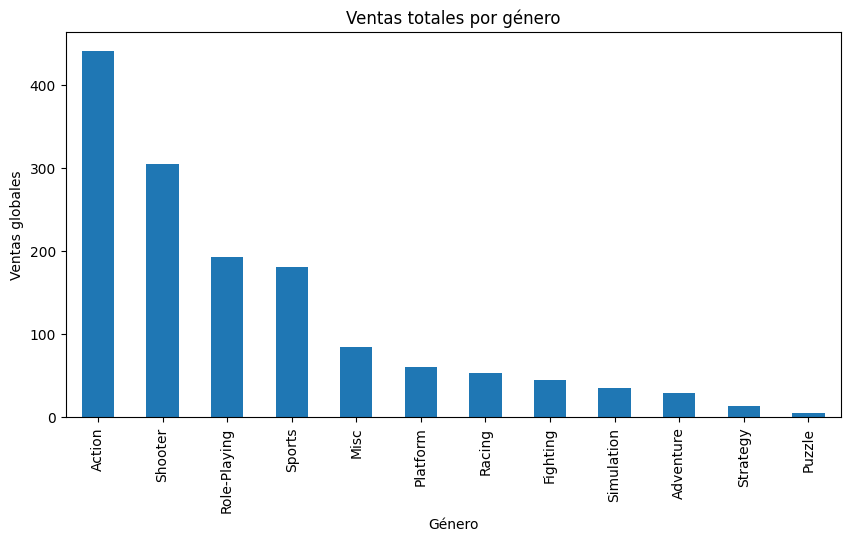

In [19]:
# 3.7 Análisis por género 

import matplotlib.pyplot as plt

genre_sales = df_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_sales.plot(kind='bar')

plt.title("Ventas totales por género")
plt.xlabel("Género")
plt.ylabel("Ventas globales")

plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


En el análisis de las ventas globales por genero se observa que los juegos de acción y shooter concentran las mayotes ventas globales. Siendo el género un factor determinante para el éxito comercial del videojuego.

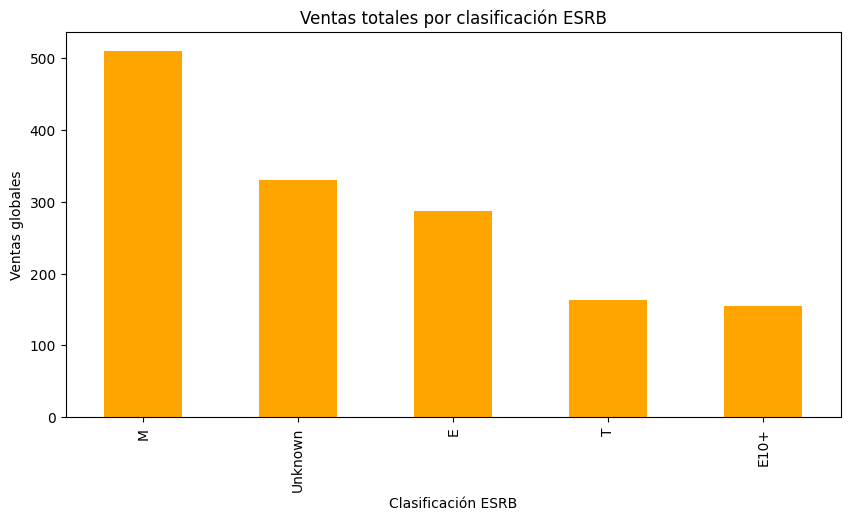

In [20]:
# 3.8 Clasificación ERSB Vs Ventas

import matplotlib.pyplot as plt

rating_sales = df_recent.groupby('rating')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
rating_sales.plot(kind='bar', color='orange')

plt.title("Ventas totales por clasificación ESRB")
plt.xlabel("Clasificación ESRB")
plt.ylabel("Ventas globales")

plt.show()

El análisis de la clasificación ESRB en relación con las ventas globales muestra que los juegos con rating M, son los que generan mayor ingreso en el mercado, seguidos por los juegos clasificados como “E” (Everyone) y “T” (Teen). La categoría “Unknown” también aparece con valores altos, aunque esto se debe principalmente a la falta de datos de clasificación en algunos juegos, por lo que no representa un segmento real del mercado.

In [21]:
# Medidas de Dispersión de ventas globales
print("Desviación estándar:", df_recent['total_sales'].std())
print("Varianza:", df_recent['total_sales'].var())

Desviación estándar: 1.2491574397518073
Varianza: 1.56039430928729


La desviación estándar muestra qué tan dispersas están las ventas entre videojuegos, mientras que la varianza indica la variabilidad total del mercado. Valores altos sugieren un mercado desigual con pocos juegos muy exitosos.

In [22]:
# PASO 4 

# 4.1 Plataformas principales por región

regions = ['na_sales', 'eu_sales', 'jp_sales']

for region in regions:
    print("\nTop plataformas en:", region)
    print(df_recent.groupby('platform')[region].sum().sort_values(ascending=False).head(5))


Top plataformas en: na_sales
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top plataformas en: eu_sales
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top plataformas en: jp_sales
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


En el análisis de las principales plataformas por región, se observa que para NA (Norteamérica) el mercado esta equilibrado entre Xbox y PlayStation, paa EU (Europa) hay un dominio claro de PlayStation y en Jp (Japon) el dominio es de Nintendo, lo que demuestra que no hay una estrategia única global y que el éxito de una campaña no depende unicamente del juego sino de la plataforma adecauda para cada región equilibrado entre Xbox y PlayStation

In [23]:
# 4.2 Géneros por región

# Norteamérica
print("Top géneros en Norteamérica")
print(df_recent.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5))

print("\nTop géneros en Europa")
print(df_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5))

print("\nTop géneros en Japón")
print(df_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5))

Top géneros en Norteamérica
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

Top géneros en Europa
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

Top géneros en Japón
genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


En el análisis de géneros por región se observa que en Norteamérica los géneros mas populares son Action, Shooter y Sports. En Europa el comportamiento del mercado es muy parecido a Norteamérica y en Japón el género dominante es Role-Playing y tambien se destaca el genero Action aunque con un peso menor. En relación con la campaña el éxito del videojuego depende también de la región. 

In [24]:
# 4.3 Clasificación ERSB Vs Ventas por región 

print("ESRB en Norteamérica")
print(df_recent.groupby('rating')['na_sales'].sum().sort_values(ascending=False))

print("\nESRB en Europa")
print(df_recent.groupby('rating')['eu_sales'].sum().sort_values(ascending=False))

print("\nESRB en Japón")
print(df_recent.groupby('rating')['jp_sales'].sum().sort_values(ascending=False))

ESRB en Norteamérica
rating
M          231.57
E          114.37
Unknown    103.31
E10+        75.70
T           66.02
Name: na_sales, dtype: float64

ESRB en Europa
rating
M          193.96
E          113.03
Unknown     91.50
E10+        55.37
T           52.96
Name: eu_sales, dtype: float64

ESRB en Japón
rating
Unknown    108.84
E           28.33
T           26.02
M           21.20
E10+         8.19
Name: jp_sales, dtype: float64


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


Los resultados me parecen correctos, sin embargo recomiendo acompañarlos con gráficas que resalten las diferencias/similitudes de las regiones
</div>


Se observa que en Norteamérica la clasificación mas vendida es M (Mature)y tambien es relevante la clasificación E (Everyone). En Europa tiene un comportamiento similar al de Norteamérica y en Japon el mayor número de ventas esta relacionado con Unkown, seguido de las categorías E y T. El ESRB influye en las ventas, pero su impacto depende de la región: es clave en Occidente, pero secundario en Japón.

In [25]:
# PASO 5 HIPOTESIS 

# HIPOTESIS 1 
from scipy import stats

xbox = df_recent[df_recent['platform'] == 'XOne']['user_score'].dropna()
pc = df_recent[df_recent['platform'] == 'PC']['user_score'].dropna()

alpha = 0.05

stat, p_value = stats.ttest_ind(xbox, pc)

print("p-value:", p_value)

if p_value < alpha:
    print("Se rechaza H0: hay diferencia significativa")
else:
    print("No se rechaza H0: no hay diferencia significativa")

p-value: 0.5747220188229722
No se rechaza H0: no hay diferencia significativa


Se estableció como hipótesis nula la igualdad entre las medias y como alternativa la existencia de una diferencia.
Se estableció un nivel de significancia de α = 0.05, lo que permite controlar el margen de error en las decisiones estadísticas. Bajo este criterio, se concluye que no existen diferencias significativas entre Xbox One y PC.
Este resultado nos indica que las valoraciones de los usuarios de las dos plataformas son similares. Por lo tanto para la campaña 2017 no es necesario diferenciar estrategias de marketing entre Xbox One y PC

In [26]:
# HIPOTESIS 2 ACTION VS SPORTS 

from scipy import stats

action = df_recent[df_recent['genre'] == 'Action']['user_score'].dropna()
sports = df_recent[df_recent['genre'] == 'Sports']['user_score'].dropna()

alpha = 0.05

stat, p_value = stats.ttest_ind(action, sports)

print("p-value:", p_value)

if p_value < alpha:
    print("Se rechaza H0: hay diferencia significativa")
else:
    print("No se rechaza H0: no hay diferencia significativa")

p-value: 1.048598937143916e-23
Se rechaza H0: hay diferencia significativa


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


Se estableció como hipótesis nula la igualdad entre las medias y como alternativa la existencia de una diferencia.
Se estableció un nivel de significancia de α = 0.05, lo que permite controlar el margen de error en las decisiones estadísticas. Bajo este criterio, se concluye que sí existen diferencias entre los géneros Action y Sports.
En relación con la campaña para 2017 esto puede afectar la estrategia de marketing dependiendo del tipo de juego que se promocione.  

PASO 6: CONCLUSIÓN GENERAL 
El mercado de videojuegos es dinamico y dependiente de factores como plataforma, genero, región y público objetivo. Se observó que las plataformas tienen ciclos de vida, donde las consolas PS3 y Xbox360 fueron reemplazadas por PS4 y XboxOne. Además las ventas varían significativamente por región entre Norteamérica, Europa y Japon.
Igau;mente se identificó que los generps de Action y Shooter son los mas rentables a nivel global, mientras que los juegos clasificados como M generan mayores ventas en los mercados occidentales.
Por otro lado, las reseñas de los usuarios y los críticos tienen cierta influencia en las ventas pero no son el factor principal de éxito. No se encontraron diferencias significativas en las valoraciones de los usuarios entre Xbox y PC, mientras que si existen diferencias entre géneros como Action y Sports. 
Por lo tanto, para el éxito de un videojuego no existe una estrategia global única, sino que las decisiones deben adaptarse a la plataforma, la región y el público.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br /> 

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div> 

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Se pueden incluir más graficas para resaltar las observaciones o datos que muestras, especialmente en la parte donde se comparan las distintas regiones del mundo

</div>
